In [1]:
%matplotlib inline
import control
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal

sns.set_style("whitegrid")

Inverted Pendulum: System Analysis


Key MATLAB commands used in this tutorial are:

[tf](http://www.mathworks.com/help/toolbox/control/ref/tf.html) , 

[ss](http://www.mathworks.com/help/toolbox/control/ref/ss.html) , 

[zpkdata](http://www.mathworks.com/help/toolbox/control/ref/zpkdata.html) , 

[impulse](http://www.mathworks.com/help/toolbox/control/ref/impulse.html) , 

[lsim](http://www.mathworks.com/help/toolbox/control/ref/lsim.html) 


From the main problem, we derived the open-loop transfer functions of the

inverted pendulum system as the following. 


$$P_{pend}(s) = \frac{\Phi(s)}{U(s)}=\frac{\frac{ml}{q}s}{s^3+\frac{b(I+ml^2)}{q}s^2-\frac{(M+m)mgl}{q}s-\frac{bmgl}{q}} \qquad [ \frac{rad}{N}]$$


$$P_{cart}(s) =  \frac{X(s)}{U(s)} = \frac{ \frac{ (I+ml^2)s^2 - gml } {q}}{s^4+\frac{b(I+ml^2)}{q}s^3-\frac{(M+m)mgl}{q}s^2-\frac{bmgl}{q}s} \qquad [ \frac{m}{N}] $$


where


$$q = (M + m)(I + ml^2) - (ml)^2$$


Recall that the above two transfer functions are valid only for small

values of the angle $\phi$, which is the angular displacement of the pendulum

from the vertically upward position. Also, the absolute pendulum angle

$\theta$ is equal to $\pi$ + $\phi$.


For the original problem setup and the derivation of the above transfer

functions, please refer to the

< ?example=InvertedPendulum&section=SystemModeling 

Inverted Pendulum: System Modeling> page.


Considering the response of the pendulum to a 1-Nsec impulse applied to

the cart, the design requirements for the pendulum are: 


* Settling time for $\theta$ of less than 5 seconds

* Pendulum angle $\theta$ never more than 0.05 radians from the vertical


Additionally, the requirements for the response of the system to a

0.2-meter step command in cart position are:


* Settling time for $x$ and $\theta$ of less than 5 seconds

* Rise time for $x$ of less than 0.5 seconds

* Pendulum angle $\theta$ never more than 20 degrees (0.35 radians) from

the vertical


Open-loop impulse response


We will begin by looking at the open-loop response of the inverted

pendulum system. Create a new [m-file](?aux=Extras_Mfile) and type

in the following commands to create the system model (refer to the main problem for the details of

getting these commands). 


In [2]:

M = 0.5
m = 0.2
b = 0.1
I = 0.006
g = 9.8
l = 0.3
q = (M+m)*(I+m*l**2)-(m*l)**2
s = control.tf('s')

P_cart = (((I+m*l**2)/q)*s**2 - (m*g*l/q))/(s**4 + (b*(I + m*l**2))*s**3/q - ((M + m)*m*g*l)*s**2/q - b*m*g*l*s/q)

P_pend = (m*l*s/q)/(s**3 + (b*(I + m*l**2))*s**2/q - ((M + m)*m*g*l)*s/q - b*m*g*l/q)

# Create MIMO transfer function system
sys_tf = control.tf([[P_cart], [P_pend]])
# Set input/output names
sys_tf.input_labels = ['u']
sys_tf.output_labels = ['x', 'phi']


We can now examine the open-loop impulse response of the system.

Specifically, we will examine how the system responds to an impulsive

force applied to the cart employing the MATLAB command |impulse|. Add the

following commands onto the end of the m-file and run it in the MATLAB

command window to get the associated plot shown below. 

Text(0.5, 1.0, 'Open-Loop Impulse Response')

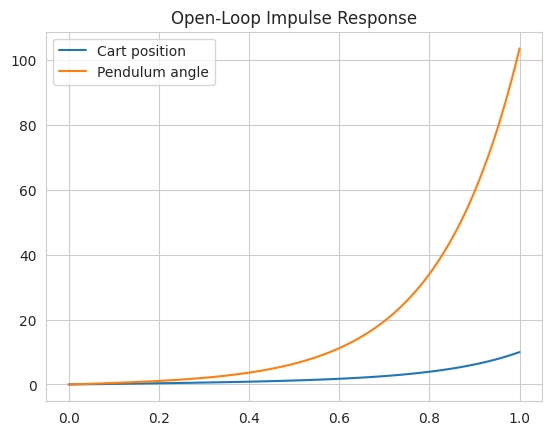

In [3]:

t=np.linspace(0, 1, int(round(1 / 0.01)) + 1)  # Evenly spaced time vector
# MIMO impulse response: call for each output
# Output 1: cart position
T1, yout1 = control.impulse_response(sys_tf[0, 0], t)
plt.plot(T1, yout1, label='Cart position')
# Output 2: pendulum angle
T2, yout2 = control.impulse_response(sys_tf[1, 0], t)
plt.plot(T2, yout2, label='Pendulum angle')
plt.legend()
plt.title('Open-Loop Impulse Response')


As you can see from the plot, the system response is entirely

unsatisfactory. In fact, it is not stable in open loop.  Although the

pendulum's position is shown to increase past 100 radians (15

revolutions), the model is only valid for small $\phi$.   

You can also see that the cart's position moves infinitely far to the

right, though there is no requirement on cart position for an impulsive

force input.


The poles of a system can also tell us about its time response.

Since our system has two outputs and one input, it is described by two

transfer functions. In general, all transfer functions from each input to

each output of a multi-input, multi-output (MIMO) system will have the

same poles (but different zeros) unless there are pole-zero

cancellations. We will specifically examine the poles and zeros of the

system using the MATLAB function |zpkdata|. The parameter |'v'| shown

below returns the poles and zeros as column vectors rather than as cell

arrays.


The zeros and poles of the system where the pendulum position is the output

are found as shown below:

In [4]:

zeros = P_pend.zeros()
poles = P_pend.poles()
dcgain_val = float(P_pend.dcgain())


Likewise, the zeros and poles of the system where the cart position is the output

are found as follows:

In [5]:

zeros = P_cart.zeros()
poles = P_cart.poles()
dcgain_val = float(P_cart.dcgain())


As predicted, the poles for both transfer functions are identical. The

pole at 5.5651 indicates that the system is unstable since the pole has

positive real part. In other words, the pole is in the right half of the

complex s-plane. This agrees with what we observed above.


Open-loop step response


Since the system has a pole with positive real part its response to a

step input will also grow unbounded. We will verify this using the |lsim|

command which can be employed to simulate the response of LTI models to

arbitrary inputs. In this case, a 1-Newton step input will be used. 

Adding the following code to your m-file and running it in the MATLAB

command window will generate the plot shown below.

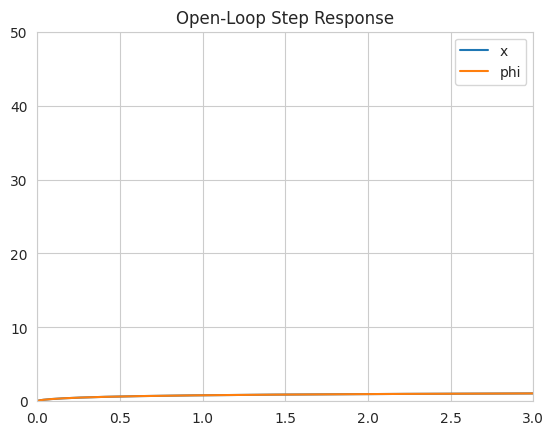

In [6]:

t = np.linspace(0, 10, int(round(10 / 0.05)) + 1)  # Evenly spaced time vector;              
u = np.ones(np.shape(t));     
# MIMO forced response: call for each output
# Output 1: cart position
y1, t1 = control.forced_response(sys_tf[0, 0], T=t, inputs=u)
# Output 2: pendulum angle
y2, t2 = control.forced_response(sys_tf[1, 0], T=t, inputs=u)
# Plot each output separately
t = t1
plt.plot(t, y1, label='x')
plt.plot(t, y2, label='phi')
plt.title('Open-Loop Step Response')
plt.axis(np.array([0, 3, 0, 50]))
plt.legend(['x', 'phi'])

plt.show()

You can also identify some important characteristics of the response

using the |lsiminfo| command as shown.

In [7]:

# lsiminfo not available - calculate step response info manually
# For step response, use step_info on individual systems
cart_info = control.step_info(sys_tf[0, 0])
pend_info = control.step_info(sys_tf[1, 0])


/projects/UMich_Controls_Tutorials_Python/venv_UMich_Controls_Tutorials_Python/lib/python3.12/site-packages/control/timeresp.py:1712: RuntimeWarning: divide by zero encountered in divide
  np.abs(yout/InfValue - 1) >= SettlingTimeThreshold)[0]
/projects/UMich_Controls_Tutorials_Python/venv_UMich_Controls_Tutorials_Python/lib/python3.12/site-packages/control/timeresp.py:1712: RuntimeWarning: invalid value encountered in divide
  np.abs(yout/InfValue - 1) >= SettlingTimeThreshold)[0]


The above results confirm our expectation that the system's response to a

step input is unstable. 


It is apparent from the analysis above that some sort of control will

need to be designed to improve the response of the system. Four example

controllers are included with these tutorials: PID, root locus, frequency

response, and state space. You may select a choice from the menu to the

left for further details.


*Note*: The solutions shown in the PID, root locus, and frequency

response examples may not yield a workable controller for the inverted pendulum 

problem. As stated previously, when we treat the inverted pendulum as a

single-input, single-output system, we ignore the position of the  

cart, $x$. Where possible in these examples, we will show what 

happens to the cart's position when a controller is implemented on the 

system.